In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file path

# Human TF promoter-level chec-seq binding signal
ATF_sumprom_glob = "sumproms/sumprom_ATF*.gz"

In [3]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import zscore
from scipy.stats import pearsonr

In [4]:
ATF_files = glob.glob(ATF_sumprom_glob)
ATF_sumprom_reps = pd.concat([pd.read_parquet(x) for x in ATF_files], axis=1)

In [5]:
cols = pd.Index(ATF_sumprom_reps.columns)
prefix = cols.to_series().str.rsplit("_", n=2).str[0]
ATF_sumprom = ATF_sumprom_reps.T.groupby(prefix).mean().T
ATF_sumprom_z = ATF_sumprom.apply(zscore, axis=0)

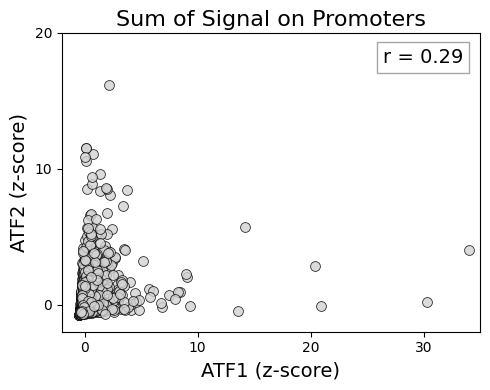

In [6]:
x = ATF_sumprom_z["ATF1"]
y = ATF_sumprom_z["ATF2"]

# Pearson correlation
r, p = pearsonr(x, y)

plt.figure(figsize=(5, 4))
plt.scatter(x, y, s=50, alpha=0.8, c="lightgrey", edgecolor="black", lw=0.6)

# -----------------------
#  Set ticks & axis limits
# -----------------------
plt.xlim(-2, 35)
plt.ylim(-2, 20)

plt.xticks([0, 10, 20, 30])
plt.yticks([0, 10, 20])

# Labels & title
plt.xlabel("ATF1 (z-score)", fontsize=14)
plt.ylabel("ATF2 (z-score)", fontsize=14)
plt.title("Sum of Signal on Promoters", pad=5, fontsize=16)


# Pearson correlation box (top right)
plt.text(
    0.96, 0.95,
    f"r = {r:.2f}",
    ha="right", va="top",
    transform=plt.gca().transAxes,
    fontsize=14,
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.7)
)

plt.tight_layout()
plt.show()